In [1]:
import os
from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

DIR_PACKAGE = Path.cwd().parent
DIR_REPO = DIR_PACKAGE.parent
if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))

from sim_data_analyzer.xr_adapters import get_lfp_xr, get_net_rate_dynamics_xr
from sim_data_analyzer.xr_signal import interp_time_outliers, filter_xr_signal
from sim_data_analyzer.xr_spect import calc_xr_cpsd, calc_xr_tf, calc_xr_welch
from sim_data_analyzer.xr_io import save_xr, load_xr
from sim_data_analyzer.xr_diff import calc_xr_bipolar, calc_xr_csd

### Load and preprocess LFP and rate dynamics

In [2]:
EXP_SRC = ('a1_lfp_30s', 'data_00000_seed_1000.pkl')
EXP_LABEL = 'a1_lfp_30s_0'

RATE_DT = 0.005

In [3]:
dirpath_src = DIR_PACKAGE / 'dev_scratch' / 'data_src'
dirpath_proc = DIR_PACKAGE / 'dev_scratch' / 'data_proc'
os.makedirs(dirpath_proc, exist_ok=True)

lfp_loaded = False
rates_loaded = False

# Try to load pre-extracted lfp
fpath_lfp = dirpath_proc / f'{EXP_LABEL}_lfp.nc'
if fpath_lfp.exists():
    lfp = load_xr(fpath_lfp)
    lfp_loaded = True
    print(f'Loaded LFP from {fpath_lfp}')

# Try to load pre-extracted rates
fpath_rates = dirpath_proc / f'{EXP_LABEL}_rates_dt_{RATE_DT}.nc'
if fpath_rates.exists():
    rates = load_xr(fpath_rates)
    rates_loaded = True
    print (f'Loaded rates from {fpath_rates}')

# If needed - load simulation result and extract lfp/rates
if (not lfp_loaded) or (not rates_loaded):
    # Load simulation result from pkl
    fpath_sim_res = dirpath_src / EXP_SRC[0] / EXP_SRC[1]
    print (f'Loading sim result from {fpath_sim_res}...')
    with fpath_sim_res.open('rb') as fid:
        sim_result = pickle.load(fid)
    print (f'Loaded sim result from {fpath_sim_res}')

    # Extract LFP
    if not lfp_loaded:
        print(f'Extracting LFP...')
        lfp = get_lfp_xr(sim_result)
        save_xr(lfp, fpath_lfp)
        print(f'Saved LFP to {fpath_lfp}')
    
    # Extract rates
    if not rates_loaded:
        print(f'Extracting rates...')
        rates = get_net_rate_dynamics_xr(sim_result, dt_bin=RATE_DT)
        save_xr(rates, fpath_rates)
        print(f'Saved rates to {fpath_rates}')


Loaded LFP from /home/nnovikov/repo/sim_data_analyzer/dev_scratch/data_proc/a1_lfp_30s_0_lfp.nc
Loaded rates from /home/nnovikov/repo/sim_data_analyzer/dev_scratch/data_proc/a1_lfp_30s_0_rates_dt_0.005.nc


In [4]:
T_LIMITS = (5, 30)

# Preprocess LFP
lfp = lfp.sel(time=slice(*T_LIMITS))
lfp = interp_time_outliers(lfp)

# Preprocess rates
rates = rates.sel(time=slice(*T_LIMITS))

# CSD
lfp = calc_xr_csd(lfp)

### Analyze data

#### Visualize LFP

(-30.0, 1.0)

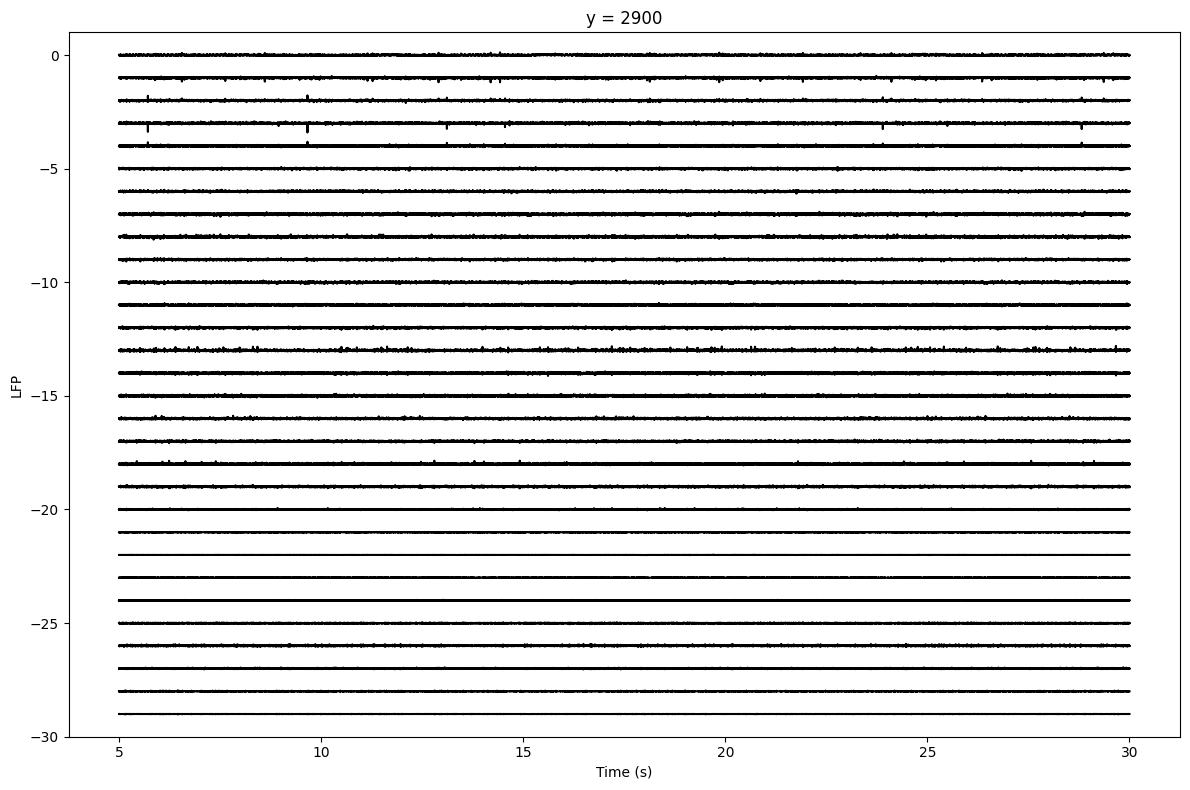

In [5]:
y_vis = lfp.y.values
mult = 0.5

# Plot LFP channels as voltage vs. time
fig, ax = plt.subplots(figsize=(12, 8))
for n, y in enumerate(y_vis):
    v = lfp.sel(y=y)
    v = (v - v.mean()) * mult - n
    v.plot(ax=ax, linestyle='-', color='k')

ax.set_xlabel('Time (s)')
ax.set_ylabel('LFP')
plt.tight_layout()

#plt.xlim(10, 15)
plt.ylim(-len(y_vis), 1)

Text(0.5, 1.0, 'LFP, y=2600')

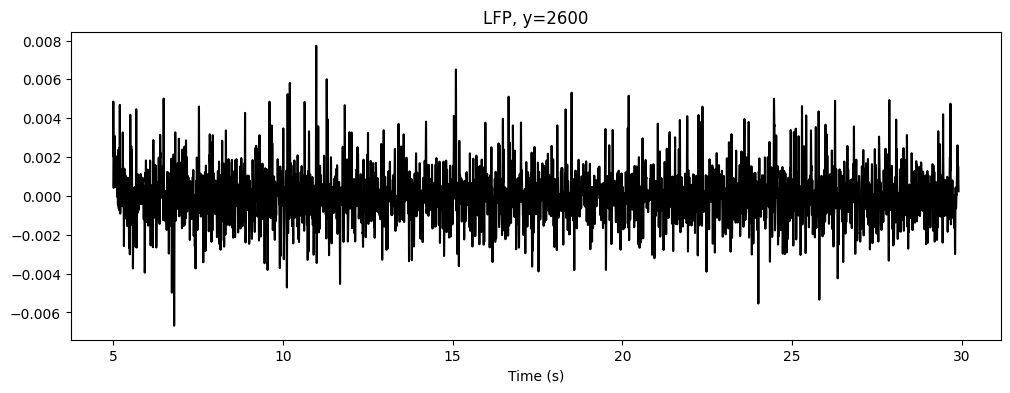

In [6]:
# Select one LFP channel
v = lfp.isel(y=-4).sel(time=slice(None, T_LIMITS[1] - 0.1))
v = v - v.mean()

# Filter LFP
vfilt = filter_xr_signal(v, fband=(1, 50))

# Plot one LFP channel
fig, ax = plt.subplots(figsize=(12, 4))
#v.plot(ax=ax, linestyle='-', color='k', alpha=0.5)
vfilt.plot(ax=ax, linestyle='-', color='k')
ax.set_xlabel('Time (s)')
ax.set_title(f'LFP, y={v.y.item()}')
#ax.set_xlim(7, 15)

#### Layer helpers

In [7]:
LAYER_Y_NORM = {
    '1': [0.00, 0.05], '2': [0.05, 0.08], '3': [0.08, 0.475], '4': [0.475, 0.625],
    '5A': [0.625, 0.667], '5B': [0.667, 0.775], '6': [0.775, 1], 'thal': [1.2, 1.4]
}

Y_SIZE = 2000

LAYER_Y = {layer: [a * Y_SIZE, b * Y_SIZE]
           for layer, (a, b) in LAYER_Y_NORM.items()}

In [8]:
def plot_layer_borders(label_xpos):
    """Add layer borders and labels. """
    for layer, (y0, y1) in LAYER_Y.items():
        # Border lines
        ax.axhline(y0, color='k', linestyle='--', linewidth=0.8, alpha=0.8)
        ax.axhline(y1, color='k', linestyle='--', linewidth=0.8, alpha=0.8)

        # Layer label at band center
        y_mid = 0.5 * (y0 + y1)
        ax.text(
            label_xpos, y_mid, layer,
            color='k', fontsize=10, ha='center', va='center',
            bbox=dict(facecolor='black', alpha=0.0, edgecolor='none', pad=1.5)
        )

#### LFP spectrum

In [9]:
psd = calc_xr_welch(lfp, win_len=2, win_overlap=0.5, fmax=100,
                    compute=True, store_proc_info=True)
psd

<xarray.DataArray (y: 30, freq: 201)> Size: 48kB
array([[4.45358890e-06, 1.48829194e-05, 6.71783946e-06, ...,
        3.55857841e-07, 3.07148273e-07, 2.66752024e-07],
       [3.12039475e-06, 1.30318571e-05, 7.24932824e-06, ...,
        1.09993867e-06, 8.26493209e-07, 6.73453587e-07],
       [1.04408976e-06, 6.60681683e-06, 6.67325368e-06, ...,
        1.20220024e-06, 1.10341256e-06, 1.23222446e-06],
       ...,
       [3.16868538e-09, 1.74404990e-08, 1.57653839e-08, ...,
        3.17372919e-08, 3.27734654e-08, 3.04127514e-08],
       [1.06019108e-09, 6.04582585e-09, 5.60123882e-09, ...,
        8.97136149e-09, 8.39830337e-09, 7.69998936e-09],
       [1.19302014e-09, 4.36551278e-09, 2.03340436e-09, ...,
        1.01797757e-09, 8.10245522e-10, 1.04071817e-09]], shape=(30, 201))
Coordinates:
  * y        (y) int32 120B 0 100 200 300 400 500 ... 2500 2600 2700 2800 2900
  * freq     (freq) float64 2kB 0.0 0.5 1.0 1.5 2.0 ... 98.5 99.0 99.5 100.0
Attributes:
    outlier_interp:  {'name': 'interp_time_outliers', 'params': {'time_dim': ...
    proc_steps:      [{'name': 'calc_xr_welch', 'params': {'win_len': 2, 'win...

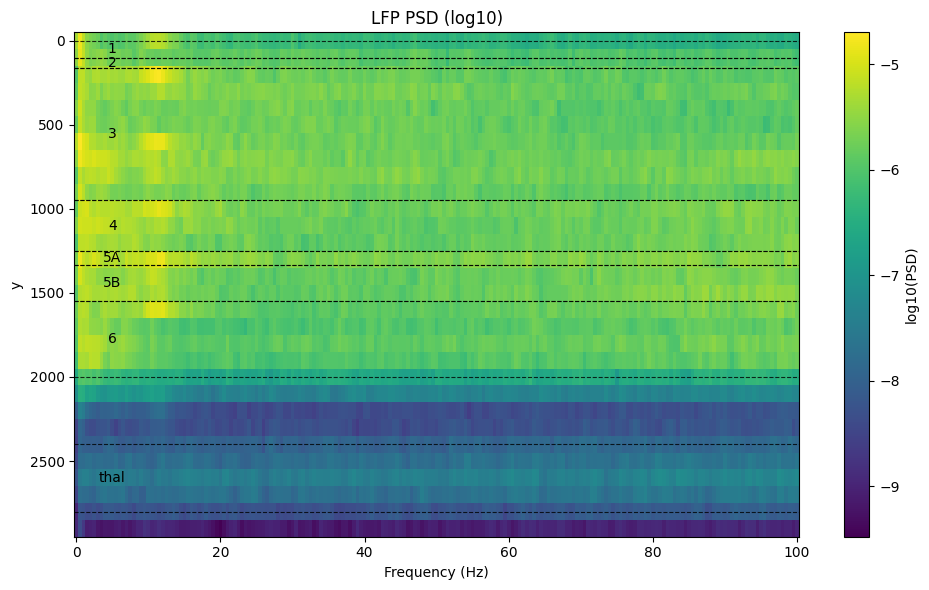

In [10]:
# 2D PSD map (freq vs y), with y increasing from top to bottom
fig, ax = plt.subplots(figsize=(10, 6))

pcm = ax.pcolormesh(
    psd.freq.values,
    psd.y.values,
    np.log10(psd.values + 1e-20),  # log scale for visibility
    shading='auto',
    cmap='viridis'
)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('y')
ax.set_title('LFP PSD (log10)')
ax.invert_yaxis()  # top-to-bottom y-axis

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('log10(PSD)')

plot_layer_borders(label_xpos=psd.freq.values.max() * 0.05)

plt.tight_layout()

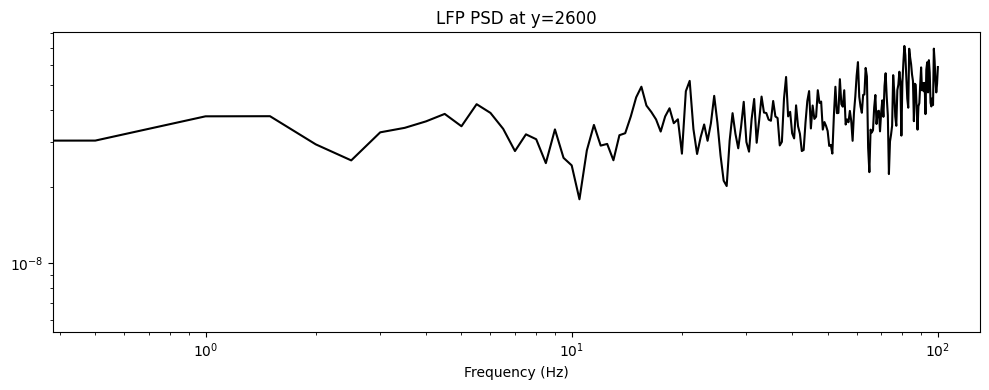

In [19]:
y_vis = 2600

fig, ax = plt.subplots(figsize=(10, 4))
psd.sel(y=y_vis).plot(ax=ax, linestyle='-', color='k')
ax.set_xlabel('Frequency (Hz)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(f'LFP PSD at y={y_vis}')
plt.tight_layout()

#### Firing rate dynamics (one channel)

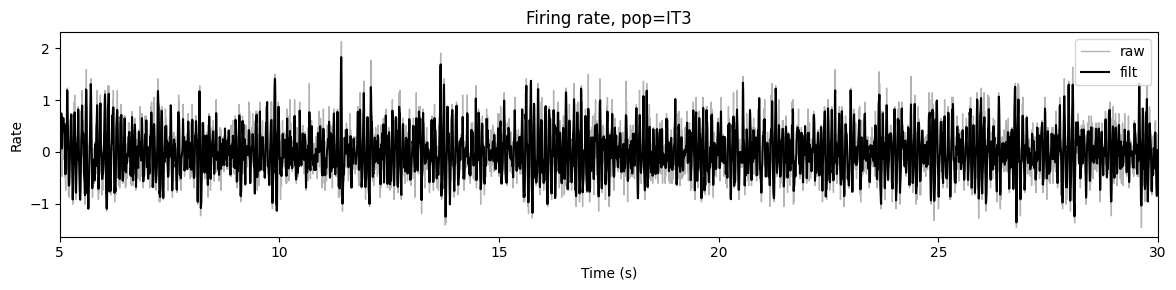

In [12]:
pop = 'IT3'

r = rates.sel(pop=pop)
r -= r.mean()
rf = filter_xr_signal(r, fband=(1, 50))

fig, ax = plt.subplots(figsize=(12, 3))

r.plot(ax=ax, color='0.7', linewidth=1, label='raw')
rf.plot(ax=ax, color='k', linewidth=1.5, label='filt')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Rate')
ax.set_title(f'Firing rate, pop={pop}')
ax.legend()
ax.set_xlim(*T_LIMITS)

plt.tight_layout()

#### Firing rate dynamics, narrowband, channel comparison

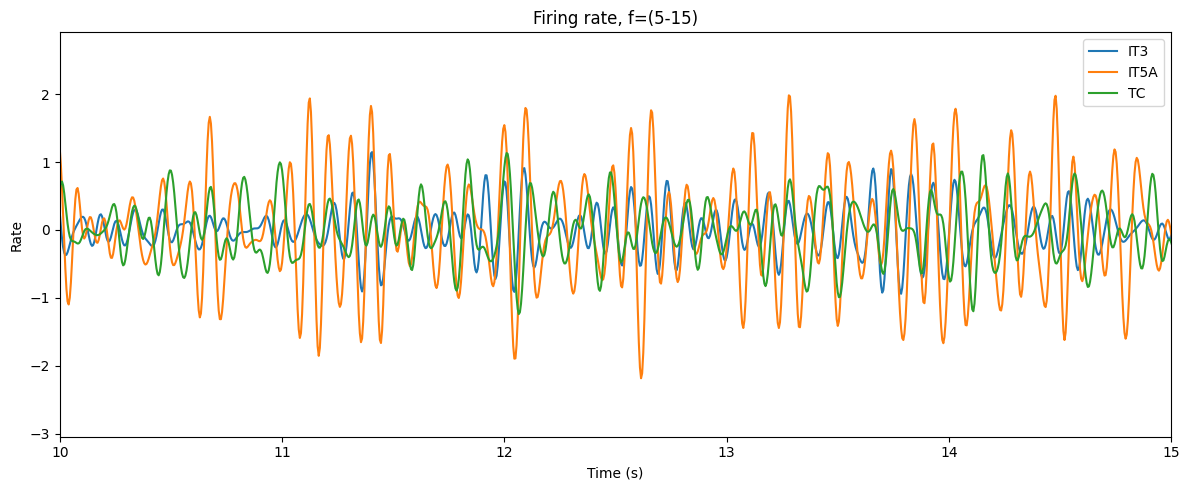

In [13]:
#pops = ['IT3', 'ITP4', 'IT5A', 'TC']
pops = ['IT3', 'IT5A', 'TC']

r = rates.sel(pop=pops)
rf = filter_xr_signal(r, fband=(5, 15))

fig, ax = plt.subplots(figsize=(12, 5))

for pop in pops:
    rf.sel(pop=pop).plot(ax=ax, linewidth=1.5, label=pop)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Rate')
ax.set_title(f'Firing rate, f=(5-15)')
ax.legend()
ax.set_xlim(10, 15)
plt.tight_layout()

Frequencies:  [ 9. 10. 11. 12. 13.]


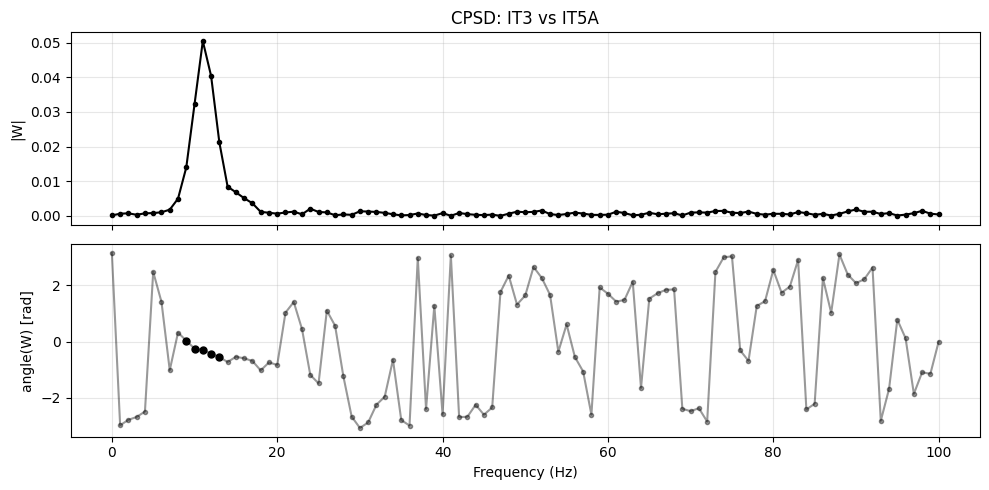

In [14]:
pop1 = 'IT3'
pop2 = 'IT5A'

W = calc_xr_cpsd(rates.sel(pop=pop1), rates.sel(pop=pop2),
                 win_len=1, win_overlap=0.5, fmax=100)
mask = np.abs(W) > 0.01

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax1.plot(W.freq.values, np.abs(W.values), color='k',
         linewidth=1.5, marker='.')
ax1.set_ylabel('|W|')
ax1.set_title(f'CPSD: {pop1} vs {pop2}')
ax1.grid(True, alpha=0.3)

ax2.plot(W.freq.values, np.angle(W.values), color='k',
         linewidth=1.5, marker='.', alpha=0.4)
ax2.plot(W.freq.values[mask], np.angle(W.values)[mask], color='k',
         marker='.', markersize=10, linewidth=0)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('angle(W) [rad]')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

print('Frequencies: ', W.freq.values[mask])

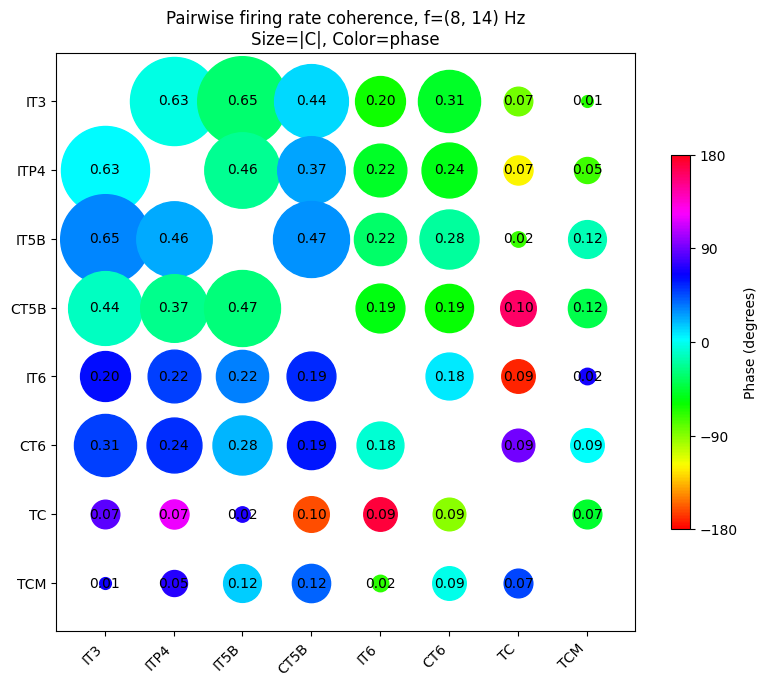

In [15]:
from itertools import combinations
from sim_data_analyzer.xr_spect import calc_xr_cpsd

#POPS_COHER = ['IT2', 'IT3', 'ITP4', 'IT5A', 'IT5B', 'PT5B', 'IT6', 'CT6', 'TC', 'TCM', 'HTC']
#POPS_COHER = ['IT2', 'IT3', 'ITP4', 'IT5A', 'IT5B', 'TC', 'TCM']
#POPS_COHER = ['IT3', 'ITP4', 'ITS4', 'IT5B', 'IT6', 'TC', 'TCM']
POPS_COHER = ['IT3', 'ITP4', 'IT5B', 'CT5B', 'IT6', 'CT6', 'TC', 'TCM']

FBAND_COHER = (8, 14)

rates_sel = rates.sel(pop=[p for p in POPS_COHER if p in rates.pop.values])
valid_pops = rates_sel.pop.values.tolist()
n_valid = len(valid_pops)

# Precompute auto-PSDs
auto_psd = {}
for p in valid_pops:
    r = rates_sel.sel(pop=p)
    auto_psd[p] = calc_xr_cpsd(r, r, win_len=1, win_overlap=0.5, fmax=100)

# Compute pairwise complex coherence
coher_da = xr.DataArray(
    np.full((n_valid, n_valid), np.nan, dtype=complex),
    coords={'pop1': valid_pops, 'pop2': valid_pops},
    dims=['pop1', 'pop2'],
    attrs={'fband': FBAND_COHER}
)

for i, p1 in enumerate(valid_pops):
    for j, p2 in enumerate(valid_pops):
        if i >= j:
            continue
        cpsd = calc_xr_cpsd(rates_sel.sel(pop=p1), rates_sel.sel(pop=p2),
                            win_len=1, win_overlap=0.5, fmax=100)
        coher = cpsd / np.sqrt(np.abs(auto_psd[p1]) * np.abs(auto_psd[p2]))
        fmask = (coher.freq >= FBAND_COHER[0]) & (coher.freq <= FBAND_COHER[1])
        coher_mean = complex(coher.sel(freq=fmask).mean().values)
        coher_da.loc[p1, p2] = coher_mean
        coher_da.loc[p2, p1] = np.conj(coher_mean)

# Plot: size = coherence magnitude, color = phase angle
# Use a cyclic colormap for phase
phase_cmap = plt.cm.hsv  # cyclic colormap for phase
max_marker_size = 80

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_aspect('equal')

for i, p1 in enumerate(valid_pops):
    for j, p2 in enumerate(valid_pops):
        if i == j:
            #ax.plot(j, -i, 'o', color='lightgrey', markersize=max_marker_size)
            continue
        val = coher_da.sel(pop1=p1, pop2=p2).item()
        if np.isnan(val):
            continue
        mag = np.abs(val)
        phase = np.angle(val)  # in [-pi, pi]
        # Normalize phase to [0, 1] for colormap
        phase_norm = (phase + np.pi) / (2 * np.pi)
        color = phase_cmap(phase_norm)
        markersize = np.sqrt(mag) * max_marker_size  # size proportional to magnitude
        ax.plot(j, -i, 'o', color=color, markersize=markersize)
        #ax.text(j, -i, f'{mag:.2f}\n{np.degrees(phase):.0f}°',
        ax.text(j, -i, f'{mag:.2f}',
                ha='center', va='center', fontsize=10, color='k')

ax.set_xticks(range(n_valid))
ax.set_xticklabels(valid_pops, rotation=45, ha='right', fontsize=10)
ax.set_yticks([-i for i in range(n_valid)])
ax.set_yticklabels(valid_pops, fontsize=10)
ax.set_title(f'Pairwise firing rate coherence, f={FBAND_COHER} Hz\nSize=|C|, Color=phase')
ax.set_xlim(-0.7, n_valid - 0.3)
ax.set_ylim(-n_valid + 0.3, 0.7)

# Colorbar for phase
sm = plt.cm.ScalarMappable(cmap=phase_cmap, norm=plt.Normalize(vmin=-180, vmax=180))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Phase (degrees)')
cbar.set_ticks([-180, -90, 0, 90, 180])

plt.tight_layout()
plt.show()


#### Phase-lag validation: CPSD on the complex plane

To check which population leads: if pop2 leads pop1 by a lag τ > 0,  
then `CSD(X1, X2) = X1* · X2` has positive angle (phase > 0).  
We verify this with a synthetic time-shifted copy and two real populations.

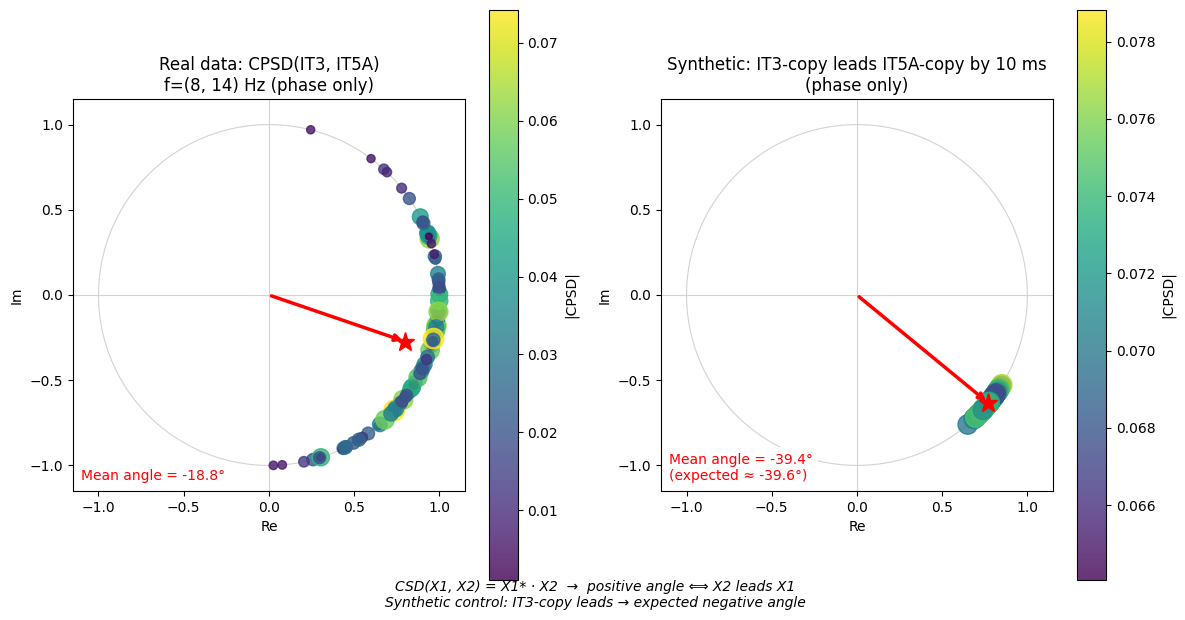

In [16]:
# ── Settings ──────────────────────────────────────────────────────────────────
POP1 = 'IT3'
POP2 = 'IT5A'
FBAND_VAL = (8, 14)          # band to inspect
WIN_LEN   = 1.0              # seconds per window
WIN_STEP  = 0.25             # seconds between window starts
LAG_SYNTH = 0.010            # synthetic lag (s): r2_synth is delayed → r1_synth leads

# ── Helpers ───────────────────────────────────────────────────────────────────
import scipy.signal as sig

def cpsd_band_mean(x1, x2, fs, nperseg, fband):
    """Complex CPSD averaged over a frequency band for one window."""
    ff, S = sig.csd(x1, x2, fs=fs, nperseg=nperseg, noverlap=0, axis=-1)
    mask = (ff >= fband[0]) & (ff <= fband[1])
    return S[mask].mean()

# ── Prepare signals ───────────────────────────────────────────────────────────
r1_raw = rates.sel(pop=POP1).values
r2_raw = rates.sel(pop=POP2).values
tt     = rates.coords['time'].values
fs_r   = round(1.0 / (tt[1] - tt[0]), 5)

# Synthetic signals: pure sine + noise, r1_synth leads r2_synth by LAG_SYNTH
fc = np.mean(FBAND_VAL)
t_synth = tt - tt[0]
rng = np.random.default_rng(42)
r1_synth = np.sin(2 * np.pi * fc * t_synth) + 0.3 * rng.standard_normal(len(tt))
r2_synth = np.sin(2 * np.pi * fc * (t_synth - LAG_SYNTH)) + 0.3 * rng.standard_normal(len(tt))

# ── Sliding-window CPSD ───────────────────────────────────────────────────────
win_samples  = round(WIN_LEN  * fs_r)
step_samples = round(WIN_STEP * fs_r)
n_total = len(tt)

cpsd_vals_real  = []
cpsd_vals_synth = []

start = 0
while start + win_samples <= n_total:
    sl = slice(start, start + win_samples)
    cpsd_vals_real.append(
        cpsd_band_mean(r1_raw[sl], r2_raw[sl], fs_r, win_samples, FBAND_VAL))
    cpsd_vals_synth.append(
        cpsd_band_mean(r1_synth[sl], r2_synth[sl], fs_r, win_samples, FBAND_VAL))
    start += step_samples

cpsd_vals_real  = np.array(cpsd_vals_real)
cpsd_vals_synth = np.array(cpsd_vals_synth)

# ── Normalize to unit circle (phase-only view) ────────────────────────────────
def normalize_phase(v):
    mag = np.abs(v)
    return np.where(mag > 0, v / mag, v)

unit_real  = normalize_phase(cpsd_vals_real)
unit_synth = normalize_phase(cpsd_vals_synth)

mag_real  = np.abs(cpsd_vals_real)
mag_synth = np.abs(cpsd_vals_synth)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

panels = [
    (axes[0], unit_real,  mag_real,
     f'Real data: CPSD({POP1}, {POP2})\nf={FBAND_VAL} Hz (phase only)',
     None),
    (axes[1], unit_synth, mag_synth,
     f'Synthetic: {POP1}-copy leads {POP2}-copy by {LAG_SYNTH*1e3:.0f} ms\n(phase only)',
     f'expected ≈ {-np.degrees(2*np.pi*fc*LAG_SYNTH):.1f}°'),
]

for ax, vals, mags, title, extra in panels:
    mean_val = vals.mean()
    mean_angle_deg = np.degrees(np.angle(mean_val))
    note = f'Mean angle = {mean_angle_deg:.1f}°'
    if extra:
        note += f'\n({extra})'

    # Unit circle
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), color='lightgrey', linewidth=0.8, zorder=0)
    ax.axhline(0, color='lightgrey', linewidth=0.8, zorder=0)
    ax.axvline(0, color='lightgrey', linewidth=0.8, zorder=0)

    # Size and color proportional to |CPSD|
    mag_norm = mags / mags.max()
    sizes  = 20 + mag_norm * 200   # range 20–220 pt²
    sc = ax.scatter(vals.real, vals.imag,
                    c=mags, cmap='viridis',
                    s=sizes, alpha=0.8, zorder=2)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label('|CPSD|')

    # Mean resultant vector
    ax.annotate('', xy=(mean_val.real, mean_val.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
    ax.plot(mean_val.real, mean_val.imag, 'r*', markersize=14, zorder=3)

    ax.set_aspect('equal')
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel('Re')
    ax.set_ylabel('Im')
    ax.set_title(title)
    ax.text(0.02, 0.02, note, transform=ax.transAxes,
            fontsize=10, va='bottom', color='red',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

fig.text(0.5, -0.02,
         'CSD(X1, X2) = X1* · X2  →  positive angle ⟺ X2 leads X1\n'
         f'Synthetic control: {POP1}-copy leads → expected negative angle',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()


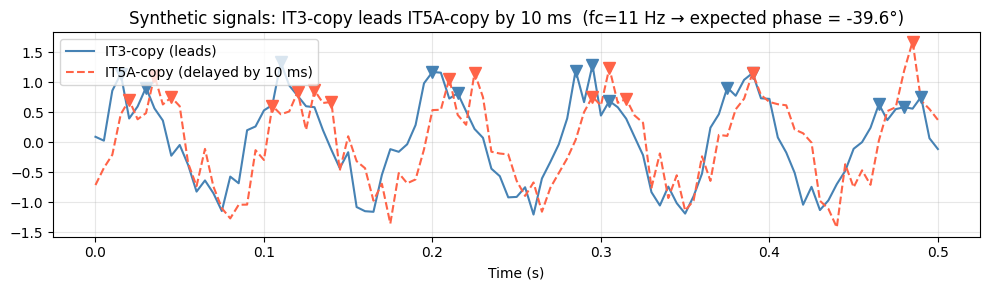

In [17]:
# Plot synthetic signals vs. time to visually confirm the phase lead
T_VIS = (0, 0.5)  # show first 0.5 s

t_mask = (t_synth >= T_VIS[0]) & (t_synth <= T_VIS[1])
t_vis  = t_synth[t_mask]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_vis, r1_synth[t_mask], label=f'{POP1}-copy (leads)', color='steelblue', linewidth=1.5)
ax.plot(t_vis, r2_synth[t_mask], label=f'{POP2}-copy (delayed by {LAG_SYNTH*1e3:.0f} ms)',
        color='tomato', linewidth=1.5, linestyle='--')

# Mark peaks of r1_synth to see the lag visually
from scipy.signal import find_peaks
peaks1, _ = find_peaks(r1_synth[t_mask], height=0.5)
peaks2, _ = find_peaks(r2_synth[t_mask], height=0.5)
ax.plot(t_vis[peaks1], r1_synth[t_mask][peaks1], 'v', color='steelblue', markersize=8)
ax.plot(t_vis[peaks2], r2_synth[t_mask][peaks2], 'v', color='tomato',    markersize=8)

ax.set_xlabel('Time (s)')
ax.set_title(f'Synthetic signals: {POP1}-copy leads {POP2}-copy by {LAG_SYNTH*1e3:.0f} ms  '
             f'(fc={fc:.0f} Hz → expected phase = {-np.degrees(2*np.pi*fc*LAG_SYNTH):.1f}°)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


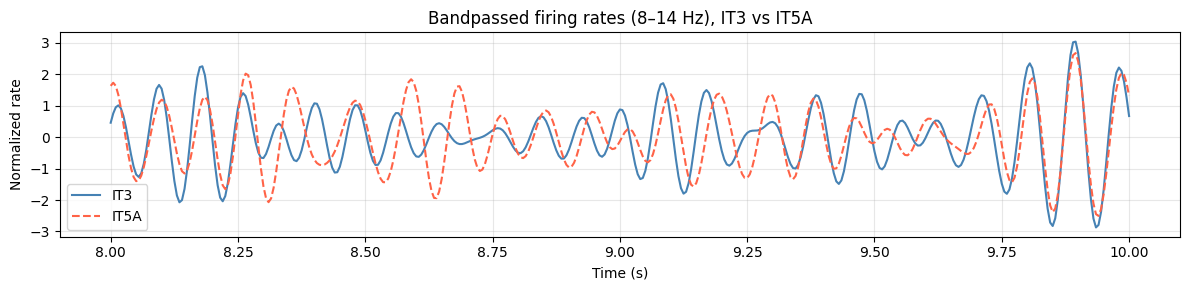

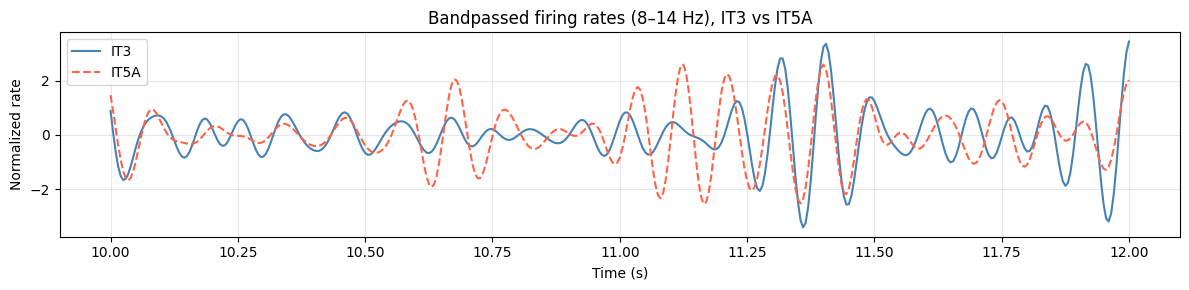

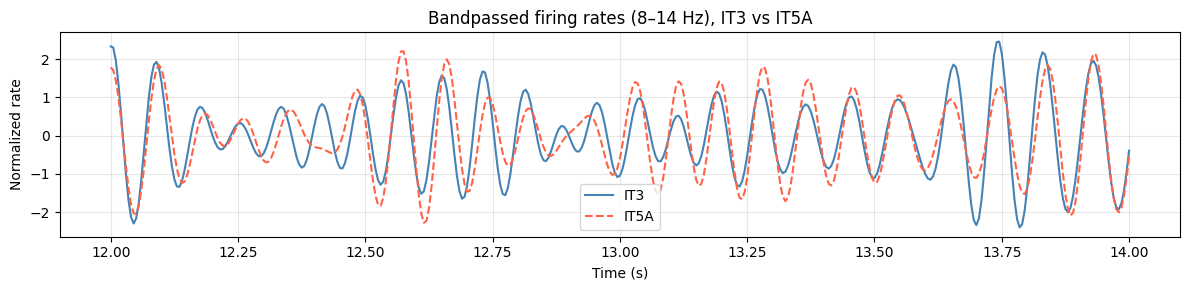

In [18]:

def plot_sigs(t1, t2):
    r1 = rates.sel(pop=POP1)
    r2 = rates.sel(pop=POP2)

    r1f = filter_xr_signal(r1 - r1.mean(), fband=FBAND_VAL)
    r2f = filter_xr_signal(r2 - r2.mean(), fband=FBAND_VAL)

    r1f = r1f.sel(time=slice(t1, t2))
    r2f = r2f.sel(time=slice(t1, t2))

    # Normalize for visual comparison
    r1f = r1f / r1f.std()
    r2f = r2f / r2f.std()

    fig, ax = plt.subplots(figsize=(12, 3))
    r1f.plot(ax=ax, label=POP1, color='steelblue', linewidth=1.5)
    r2f.plot(ax=ax, label=POP2, color='tomato',    linewidth=1.5, linestyle='--')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized rate')
    ax.set_title(f'Bandpassed firing rates ({FBAND_VAL[0]}–{FBAND_VAL[1]} Hz), {POP1} vs {POP2}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_sigs(8, 10)
plot_sigs(10, 12)
plot_sigs(12, 14)
